##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

Upload 5 images for Pascal VOC classes:


Saving bird.jpg to bird.jpg
Saving golden retriever.jpg to golden retriever (1).jpg
Saving sports car.jpg to sports car (1).jpg
Saving tabby cat.jpg to tabby cat (1).jpg
Saving train.jpg to train.jpg

Results for bird.jpg:
 - Bird: 0.98

Results for golden retriever (1).jpg:
 - Dog: 0.84

Results for sports car (1).jpg:
 - Car: 0.97

Results for tabby cat (1).jpg:
 - Cat: 0.99

Results for train.jpg:
 - Train: 0.98


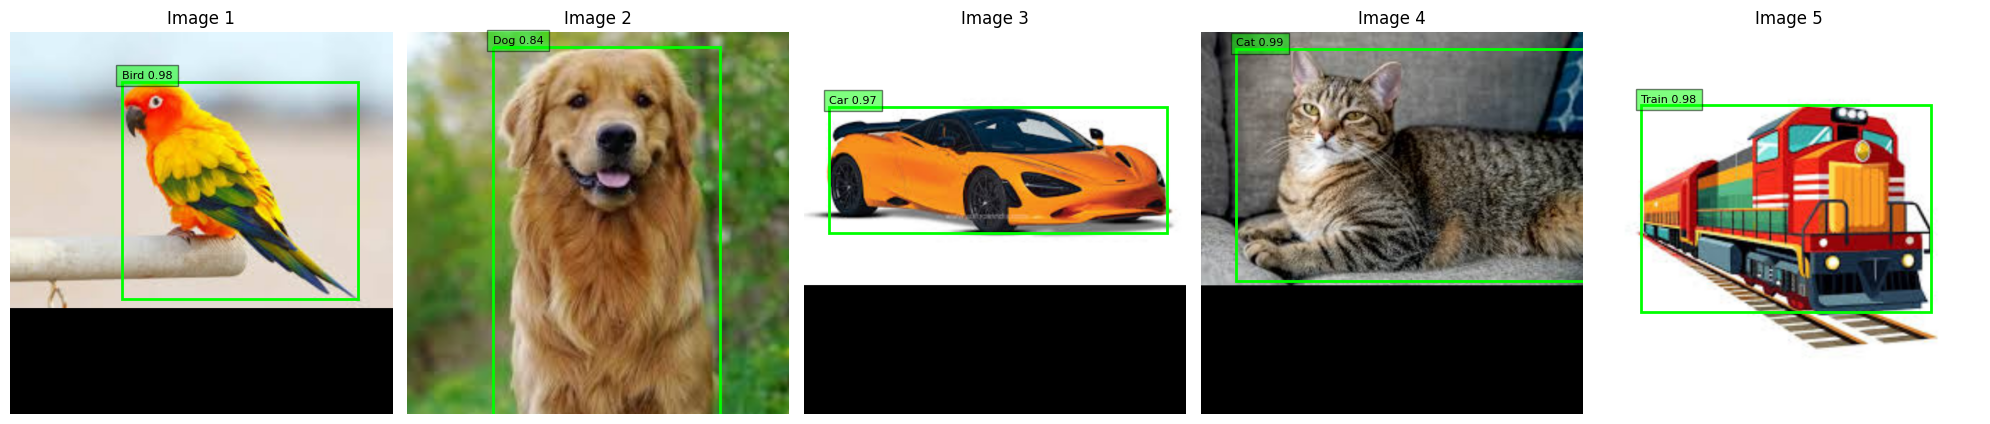

In [2]:
# --- 1. Install Compatible Versions ---
!pip install -q --upgrade keras-cv keras-hub keras

import os
os.environ["KERAS_BACKEND"] = "tensorflow" # Ensure we use the correct backend

import numpy as np
import matplotlib.pyplot as plt
import PIL.Image
import keras
import keras_cv
from google.colab import files

# --- 2. Load Pre-trained YOLOV8 Model ---
# Using the Pascal VOC preset as required
model_preset = "yolo_v8_m_pascalvoc"
detector = keras_cv.models.YOLOV8Detector.from_preset(
    model_preset,
    load_weights=True,
)

# --- 3. Required Inference Resizing Layer ---
# Mandatory 640x640 resize with aspect ratio padding
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

# --- 4. Define Pascal VOC Classes ---
class_ids = [
    "Airplane", "Bicycle", "Bird", "Boat", "Bottle", "Bus", "Car", "Cat",
    "Chair", "Cow", "Dining Table", "Dog", "Horse", "Motorbike",
    "Person", "Potted Plant", "Sheep", "Sofa", "Train", "TV Monitor"
]
class_mapping = dict(enumerate(class_ids))

# --- 5. Upload and Predict ---
print("Upload 5 images for Pascal VOC classes:")
uploaded = files.upload()
uploaded_filenames = list(uploaded.keys())[:5]

plt.figure(figsize=(20, 10))

for i, filename in enumerate(uploaded_filenames):
    # Load and prepare image
    img = PIL.Image.open(filename).convert("RGB")
    img_array = np.array(img)
    image_batch = np.expand_dims(img_array, axis=0)

    # Apply resizing
    resized_image = inference_resizing(image_batch)

    # Inference
    y_pred = detector.predict(resized_image, verbose=0)

    # Extract results
    boxes = y_pred['boxes'][0]
    classes = y_pred['classes'][0]
    confidences = y_pred['confidence'][0]

    # Visualization
    plt.subplot(1, 5, i + 1)
    plt.imshow(resized_image[0].numpy().astype("uint8"))
    ax = plt.gca()

    print(f"\nResults for {filename}:")
    for j in range(len(confidences)):
        conf = confidences[j]
        if conf < 0.4: continue # Threshold

        class_name = class_mapping.get(int(classes[j]), "Unknown")
        x, y, w, h = boxes[j]

        rect = plt.Rectangle((x, y), w, h, fill=False, color="lime", linewidth=2)
        ax.add_patch(rect)
        plt.text(x, y - 5, f"{class_name} {conf:.2f}",
                 bbox=dict(facecolor='lime', alpha=0.5), fontsize=8)

        print(f" - {class_name}: {conf:.2f}")

    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.tight_layout()
plt.show()